# Phase 2 — Exploratory Data Analysis & Data Quality
## Hospital Operations & Revenue Risk Intelligence Platform

**Business Goal:** Understand hospital operations, financial performance, and
data reliability before deploying AI models.

**Rubric tasks covered:**
- ✅ Load data into Python and combine all three datasets
- ✅ Analyse missing values in `approved_amount`, `payment_days`, `length_of_stay_hours`
- ✅ Distribution analysis by department, visit_type, insurance_provider, city
- ✅ Detect and classify outliers in `billed_amount`, `payment_days`, `length_of_stay_hours`
- ✅ Feature engineering — visit frequency, avg LOS per patient, provider rejection rate,
  days since registration, approval ratio, capped columns, time-based features

**Imports from Utils/:**
- `phase1_utils.py` — database setup, feature engineering, encoding, constants
- `phase2_utils.py` — all EDA plotting and analysis functions

**Outputs → `Output_Phase2/`:**
`model_table.csv` · `missing_values.png` · `dist_department.png` · `dist_pie_charts.png`
`dist_insurer.png` · `dist_city.png` · `outlier_analysis.png` · `correlation_heatmap.png`
`feature_vs_risk.png` · `feature_vs_claim.png`


## 1. Imports & Setup

In [1]:
# ── Imports from Utils/ ───────────────────────────────────────────────────────
# Utils/ is marked as Sources Root in PyCharm — no sys.path needed

# phase1_utils: foundation layer used by all phases
from phase1_utils import (
    notebook_setup,        # one-call: pandas config, plot style, DB, merged DF, output folder
    engineer_features,     # all 11 feature engineering steps in one call
    encode_categoricals,   # fixed label encoding consistent with Phase 3 & 5
    build_model_table,     # engineer + encode + select final model columns
    MODEL_A_FEATURES,      # 18 features for Model A (visit risk)
    MODEL_B_FEATURES,      # 18 features for Model B (claim outcome)
    MODEL_A_TARGET,        # 'risk_score_encoded'
    MODEL_B_TARGET,        # 'claim_status_encoded'
)

# phase2_utils: all EDA plotting and analysis functions
from phase2_utils import (
    missing_value_summary,    # null count + pct table
    plot_missing_values,      # bar chart + monthly heatmap
    explain_missing_nulls,    # why nulls exist per claim_status
    plot_distributions,       # dept, pie charts, insurer, city (4 chart files)
    iqr_summary,              # IQR stats for one column → returns (lower, upper)
    zscore_summary,           # z-score outlier count for one column
    plot_outliers,            # 2×3 histogram + boxplot grid
    plot_correlation,         # lower-triangle correlation heatmap
    plot_feature_vs_target,   # feature boxplots by risk_score & claim_status
)

import pandas as pd
from IPython.display import display

# ── One-call setup ────────────────────────────────────────────────────────────
# This single call handles everything:
#   ✅ pandas display options  (no scientific notation, all columns visible)
#   ✅ consistent plot style   (same look across all phase notebooks)
#   ✅ loads CSVs → SQLite DB  (with Phase 1 indexes and views)
#   ✅ builds merged DataFrame (visits + patients + billing)
#   ✅ creates Output_Phase2/  (saves all charts and CSV here)

ctx = notebook_setup('Output_Phase2')

con      = ctx['con']       # SQLite connection (for any inline SQL checks)
df       = ctx['df']        # merged DataFrame: 25,000 rows × 20 columns
out      = ctx['out']       # path helper: out('file.png') → 'Output_Phase2/file.png'
patients = ctx['patients']  # raw patients table
visits   = ctx['visits']    # raw visits table
billing  = ctx['billing']   # raw billing table


🔧 phase1_utils — notebook setup
────────────────────────────────────────
📦 Loading CSVs into SQLite...
  patients :  5,000 rows × 7 cols
  visits   : 25,000 rows × 8 cols
  billing  : 25,000 rows × 7 cols
  ✅ SQLite DB ready — 7 indexes + 2 views created.
🔗 Building merged DataFrame...
  Merged shape : 25,000 rows × 20 columns
  Date range   : 2025-01-20 → 2026-01-20
📁 Creating output folder...
  ✅ Output folder ready → S:\Emeritus_Course slides\Capstone_Project\Output_Phase2/
────────────────────────────────────────
✅ Setup complete. Everything is ready.



## 2. Dataset Overview

After merging all three tables we have a single analysis-ready DataFrame.
This is the same join that the Phase 1 view `vw_hospital_master` performs in SQL —
now in pandas for Python-based EDA and ML work.


In [2]:
print(f"Shape         : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"Date range    : {df['visit_date'].min().date()}  →  {df['visit_date'].max().date()}")
print(f"Unique patients: {df['patient_id'].nunique():,}")
print(f"Unique visits  : {df['visit_id'].nunique():,}")
print()
display(df.head(3))


Shape         : 25,000 rows  ×  20 columns
Date range    : 2025-01-20  →  2026-01-20
Unique patients: 4,967
Unique visits  : 25,000



,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,city,insurance_provider,chronic_flag,registration_date,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,Bangalore,CareOne,1,2025-08-14,1,"23,577.37",0.00,Rejected,16.00,2025-06-18
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,Hyderabad,SecureLife,1,2025-10-29,2,"38,178.81","38,178.81",Paid,18.00,2025-10-09
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,Chennai,HealthPlus,1,2025-07-04,3,"5,038.97","5,038.97",Paid,NaN,2025-01-20


In [3]:
print("Column names and dtypes:")
print(df.dtypes.to_string())


Column names and dtypes:
visit_id                         int64
patient_id                       int64
visit_date              datetime64[us]
department                         str
visit_type                         str
length_of_stay_hours           float64
risk_score                         str
doctor_id                        int64
age                              int64
gender                             str
city                               str
insurance_provider                 str
chronic_flag                     int64
registration_date       datetime64[us]
bill_id                          int64
billed_amount                  float64
approved_amount                float64
claim_status                       str
payment_days                   float64
billing_date            datetime64[us]


## 3. Missing Value Analysis

**Rubric requirement:** Analyse missing values in `approved_amount`,
`payment_days`, and `length_of_stay_hours`.

Missing data is the most common data quality problem in healthcare.
We need to understand how many values are missing, which columns, and
**why** — so we can choose the right imputation strategy in Phase 3.


In [4]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = missing_value_summary(df)
print("Columns with missing values:")
display(summary)
print(f"\nTotal records  : {len(df):,}")
print(f"Total nulls    : {df.isnull().sum().sum():,}  "
      f"({df.isnull().mean().mean()*100:.3f}% of all cells)")
print(f"length_of_stay : {df['length_of_stay_hours'].isnull().sum()} nulls  ✅ Clean")


Columns with missing values:


,null_count,null_pct,dtype
approved_amount,1318,5.27,float64
payment_days,790,3.16,float64



Total records  : 25,000
Total nulls    : 2,108  (0.422% of all cells)
length_of_stay : 0 nulls  ✅ Clean


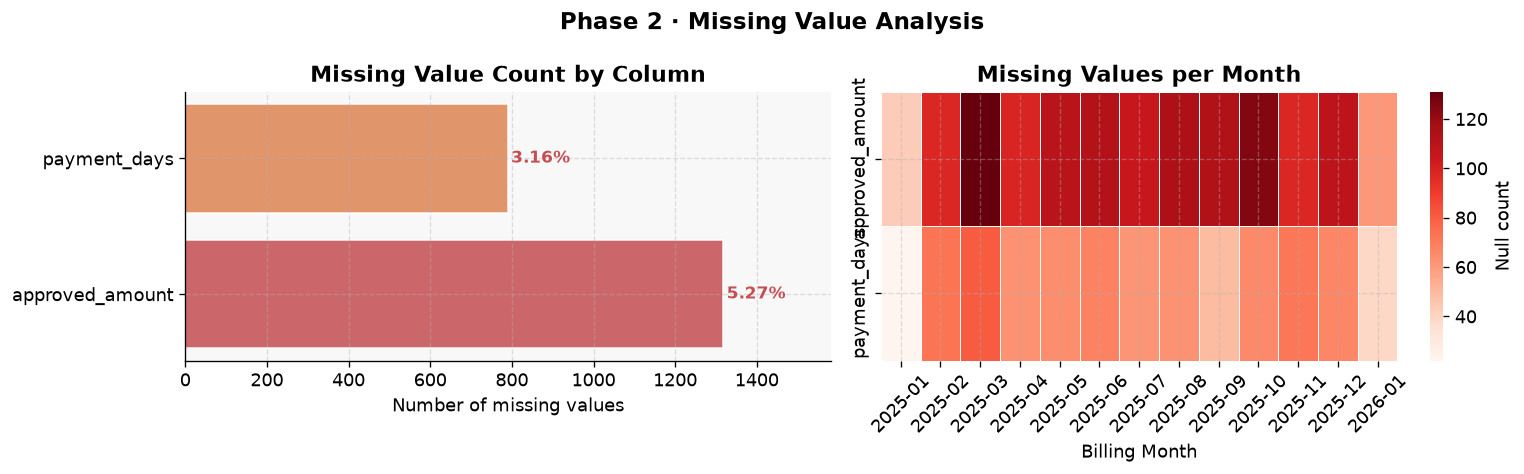

  ✅ Saved → Output_Phase2\missing_values.png


In [5]:
# ── Visualise: bar chart + monthly heatmap ────────────────────────────────────
plot_missing_values(df, out=out)


In [6]:
# ── Understand WHY values are missing ────────────────────────────────────────
explain_missing_nulls(df)


=== approved_amount nulls by claim_status ===


,total,nulls,null_pct
claim_status,,,
Paid,"14,940.00",817.00,5.50
Pending,"6,263.00",301.00,4.80
Rejected,"3,797.00",200.00,5.30



=== payment_days nulls by claim_status ===


,total,nulls,null_pct
claim_status,,,
Paid,"14,940.00",459.00,3.10
Pending,"6,263.00",208.00,3.30
Rejected,"3,797.00",123.00,3.20



💡 Interpretation:
   - approved_amount is NULL when the insurer has not yet responded
     (Pending) or approved ₹0 (some Rejected cases).
   - payment_days is NULL when no payment has been received yet
     (Pending and Rejected claims).
   - These are INFORMATIVE nulls — they carry business meaning.
     Strategy: Rejected → 0,  Pending → median,  Paid → keep as-is.


## 4. Distribution Analysis

**Rubric requirement:** Distribution analysis by `department`, `visit_type`,
`insurance_provider`, and `city`.

We examine how visits and billing records are distributed across these
dimensions to reveal operational patterns and class imbalances the ML
models must handle.


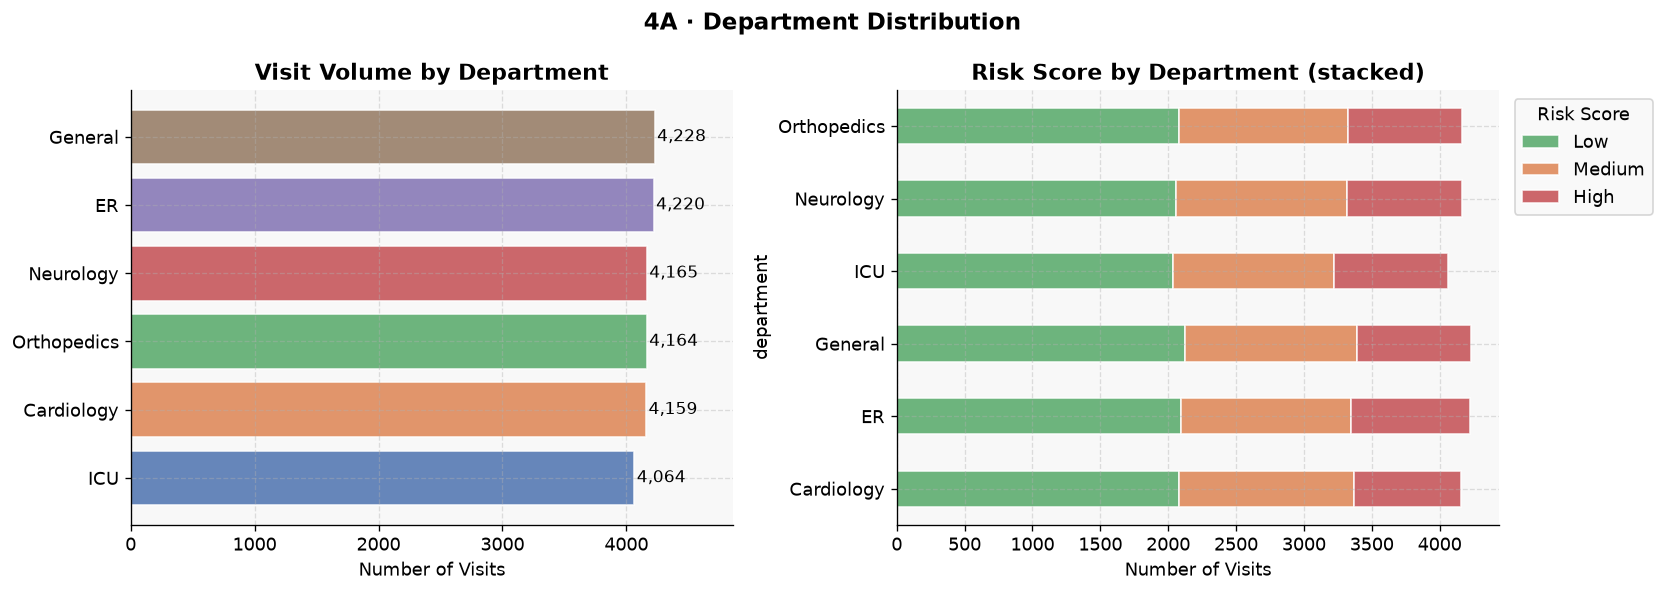

  ✅ Saved → Output_Phase2\dist_department.png


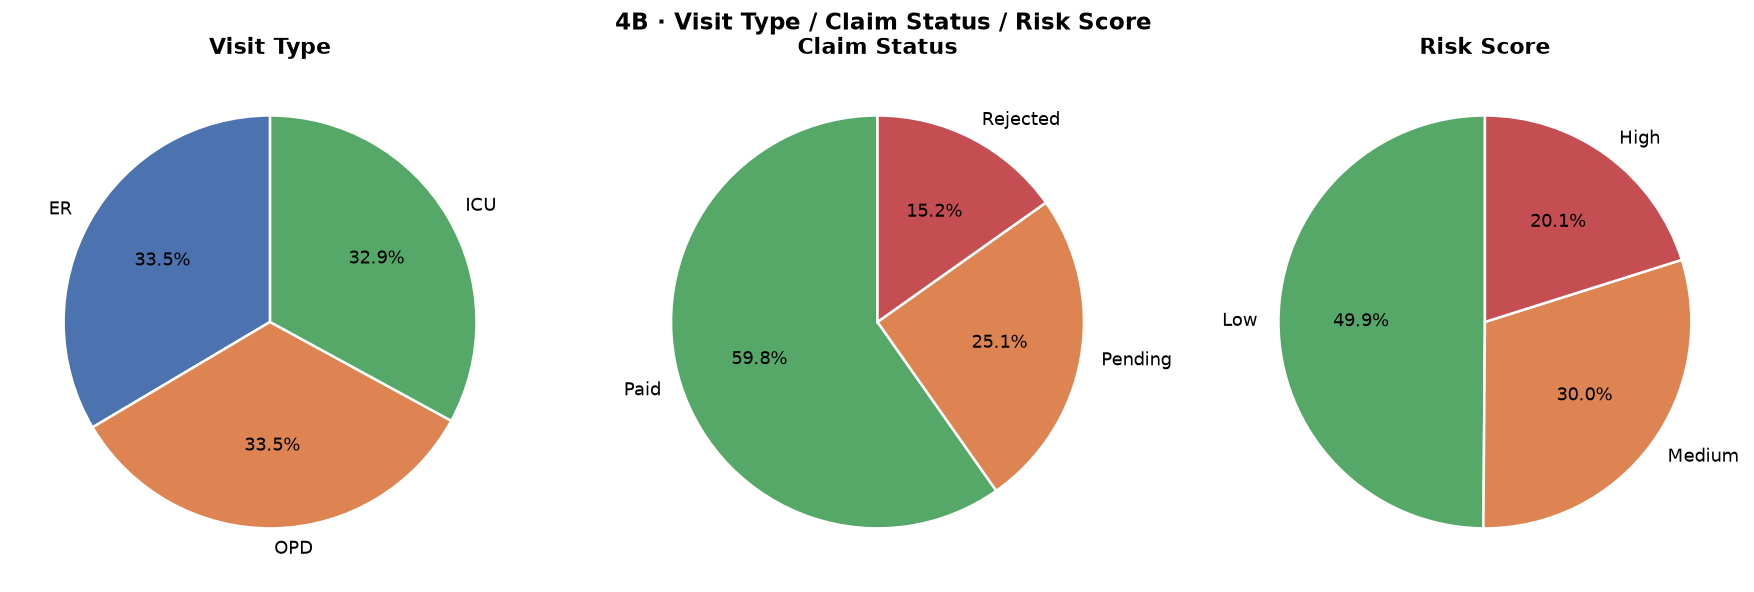

  ✅ Saved → Output_Phase2\dist_pie_charts.png
💡 ~20% High Risk visits, ~15% Rejected claims — moderate class imbalance to handle with class_weight='balanced' in Phase 3.


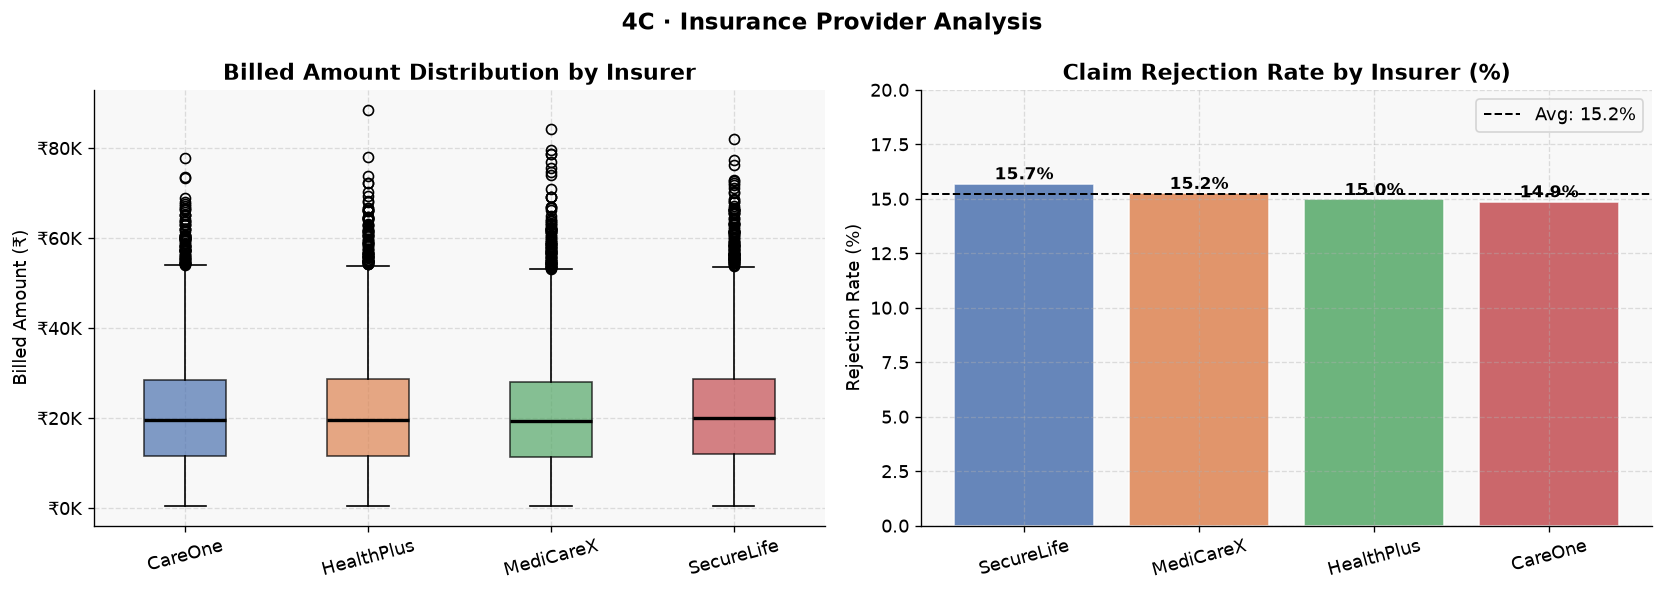

  ✅ Saved → Output_Phase2\dist_insurer.png


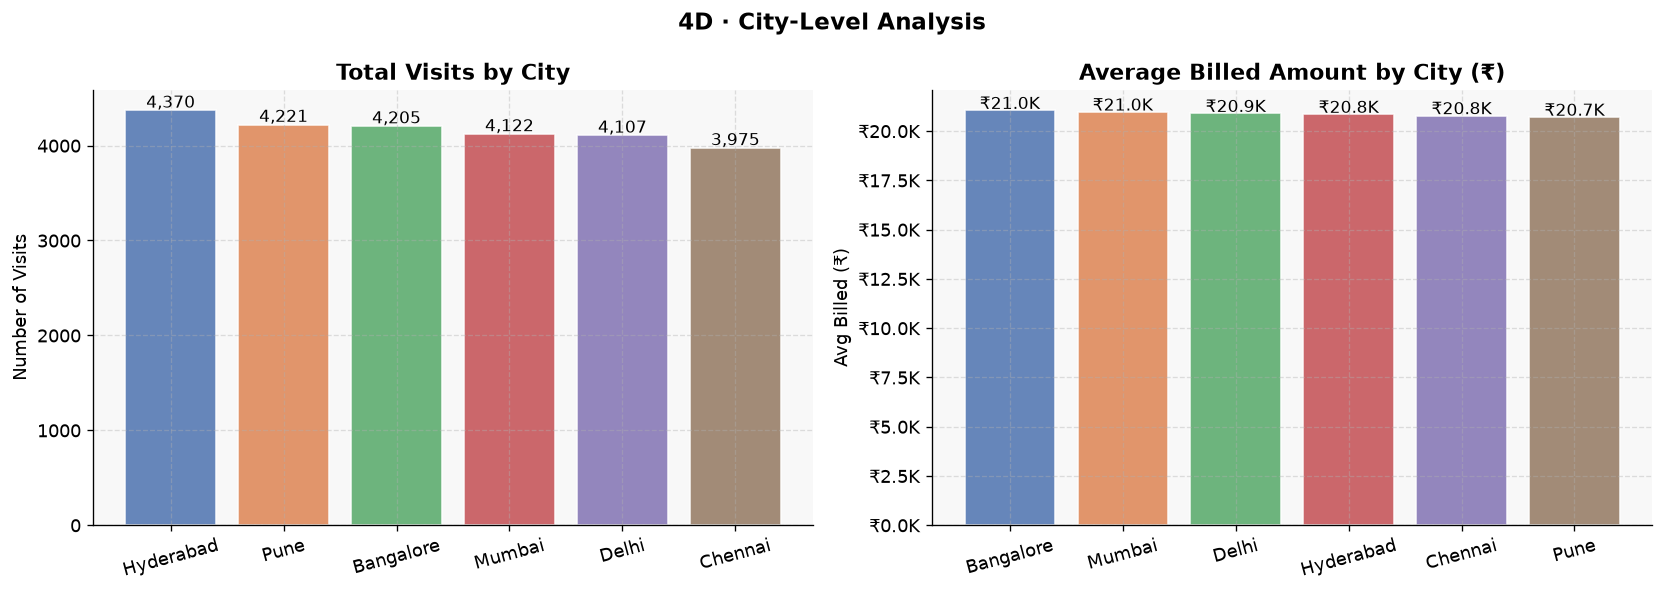

  ✅ Saved → Output_Phase2\dist_city.png


In [7]:
# Generates and saves 4 chart files to Output_Phase2/:
#   dist_department.png   — visit volume + risk stacked bar by department
#   dist_pie_charts.png   — pie charts: visit type, claim status, risk score
#   dist_insurer.png      — billed amount box plot + rejection rate by insurer
#   dist_city.png         — visit volume + avg billed amount by city

plot_distributions(df, out=out)


In [8]:
# ── Quick numeric summary of key distributions ────────────────────────────────
print("=== Visit type distribution ===")
display(df['visit_type'].value_counts().to_frame('count').assign(
    pct=lambda x: (x['count']/len(df)*100).round(2)
))

print("\n=== Risk score distribution ===")
display(df['risk_score'].value_counts().to_frame('count').assign(
    pct=lambda x: (x['count']/len(df)*100).round(2)
))

print("\n=== Claim status distribution ===")
display(df['claim_status'].value_counts().to_frame('count').assign(
    pct=lambda x: (x['count']/len(df)*100).round(2)
))

print("""
💡 Class imbalance notes for Phase 3:
   Model A (risk_score)   : Low 49.9% / Medium 30.0% / High 20.1%
   Model B (claim_status) : Paid 59.8% / Pending 25.1% / Rejected 15.2%
   Both models will use class_weight='balanced' to handle this.""")


=== Visit type distribution ===


,count,pct
visit_type,,
ER,8382,33.53
OPD,8381,33.52
ICU,8237,32.95



=== Risk score distribution ===


,count,pct
risk_score,,
Low,12470,49.88
Medium,7496,29.98
High,5034,20.14



=== Claim status distribution ===


,count,pct
claim_status,,
Paid,14940,59.76
Pending,6263,25.05
Rejected,3797,15.19



💡 Class imbalance notes for Phase 3:
   Model A (risk_score)   : Low 49.9% / Medium 30.0% / High 20.1%
   Model B (claim_status) : Paid 59.8% / Pending 25.1% / Rejected 15.2%
   Both models will use class_weight='balanced' to handle this.


## 5. Outlier Detection

**Rubric requirement:** Detect and classify outliers in `billed_amount`,
`payment_days`, and `length_of_stay_hours`.

We use two complementary methods:
- **IQR method** — values beyond 1.5×IQR from Q1/Q3
- **Z-score method** — values more than 3 standard deviations from the mean

**Strategy: CAP, do not remove.**
Removing rows in a clinical dataset risks losing real extreme cases —
a 70-hour ICU stay is a genuine clinical event, not a data error.


In [9]:
print("=== IQR Outlier Analysis ===\n")
ba_lo, ba_hi = iqr_summary(df['billed_amount'],        'billed_amount (₹)')
pd_lo, pd_hi = iqr_summary(df['payment_days'].dropna(),'payment_days (days)')
lo_lo, lo_hi = iqr_summary(df['length_of_stay_hours'], 'length_of_stay_hours')


=== IQR Outlier Analysis ===

billed_amount (₹)
  Q1=11,582.45   Q3=28,398.07   IQR=16,815.62
  Lower fence=0.00   Upper fence=53,621.49
  Outliers: 373  (1.49%)

payment_days (days)
  Q1=8.00   Q3=17.00   IQR=9.00
  Lower fence=0.00   Upper fence=30.50
  Outliers: 509  (2.10%)

length_of_stay_hours
  Q1=9.96   Q3=27.31   IQR=17.35
  Lower fence=0.00   Upper fence=53.34
  Outliers: 256  (1.02%)



In [10]:
print("=== Z-score Outlier Analysis (|z| > 3) ===\n")
n_ba = zscore_summary(df['billed_amount'],        'billed_amount       ')
n_pd = zscore_summary(df['payment_days'],         'payment_days        ')
n_lo = zscore_summary(df['length_of_stay_hours'], 'length_of_stay_hours')

print(f"""
💡 Outlier strategy summary:
   billed_amount     : {n_ba} outliers → CAP at IQR upper fence ₹{ba_hi:,.0f}
   payment_days      : {n_pd} outliers → CAP at IQR upper fence {pd_hi:.1f} days
   length_of_stay    : {n_lo} outliers → CAP at IQR upper fence {lo_hi:.1f} hours
   Capping preserves all records while reducing extreme value influence.""")


=== Z-score Outlier Analysis (|z| > 3) ===

  billed_amount               : 190 outliers (0.76%)  at |z| > 3
  payment_days                : 232 outliers (0.93%)  at |z| > 3
  length_of_stay_hours        : 142 outliers (0.57%)  at |z| > 3

💡 Outlier strategy summary:
   billed_amount     : 190 outliers → CAP at IQR upper fence ₹53,621
   payment_days      : 232 outliers → CAP at IQR upper fence 30.5 days
   length_of_stay    : 142 outliers → CAP at IQR upper fence 53.3 hours
   Capping preserves all records while reducing extreme value influence.


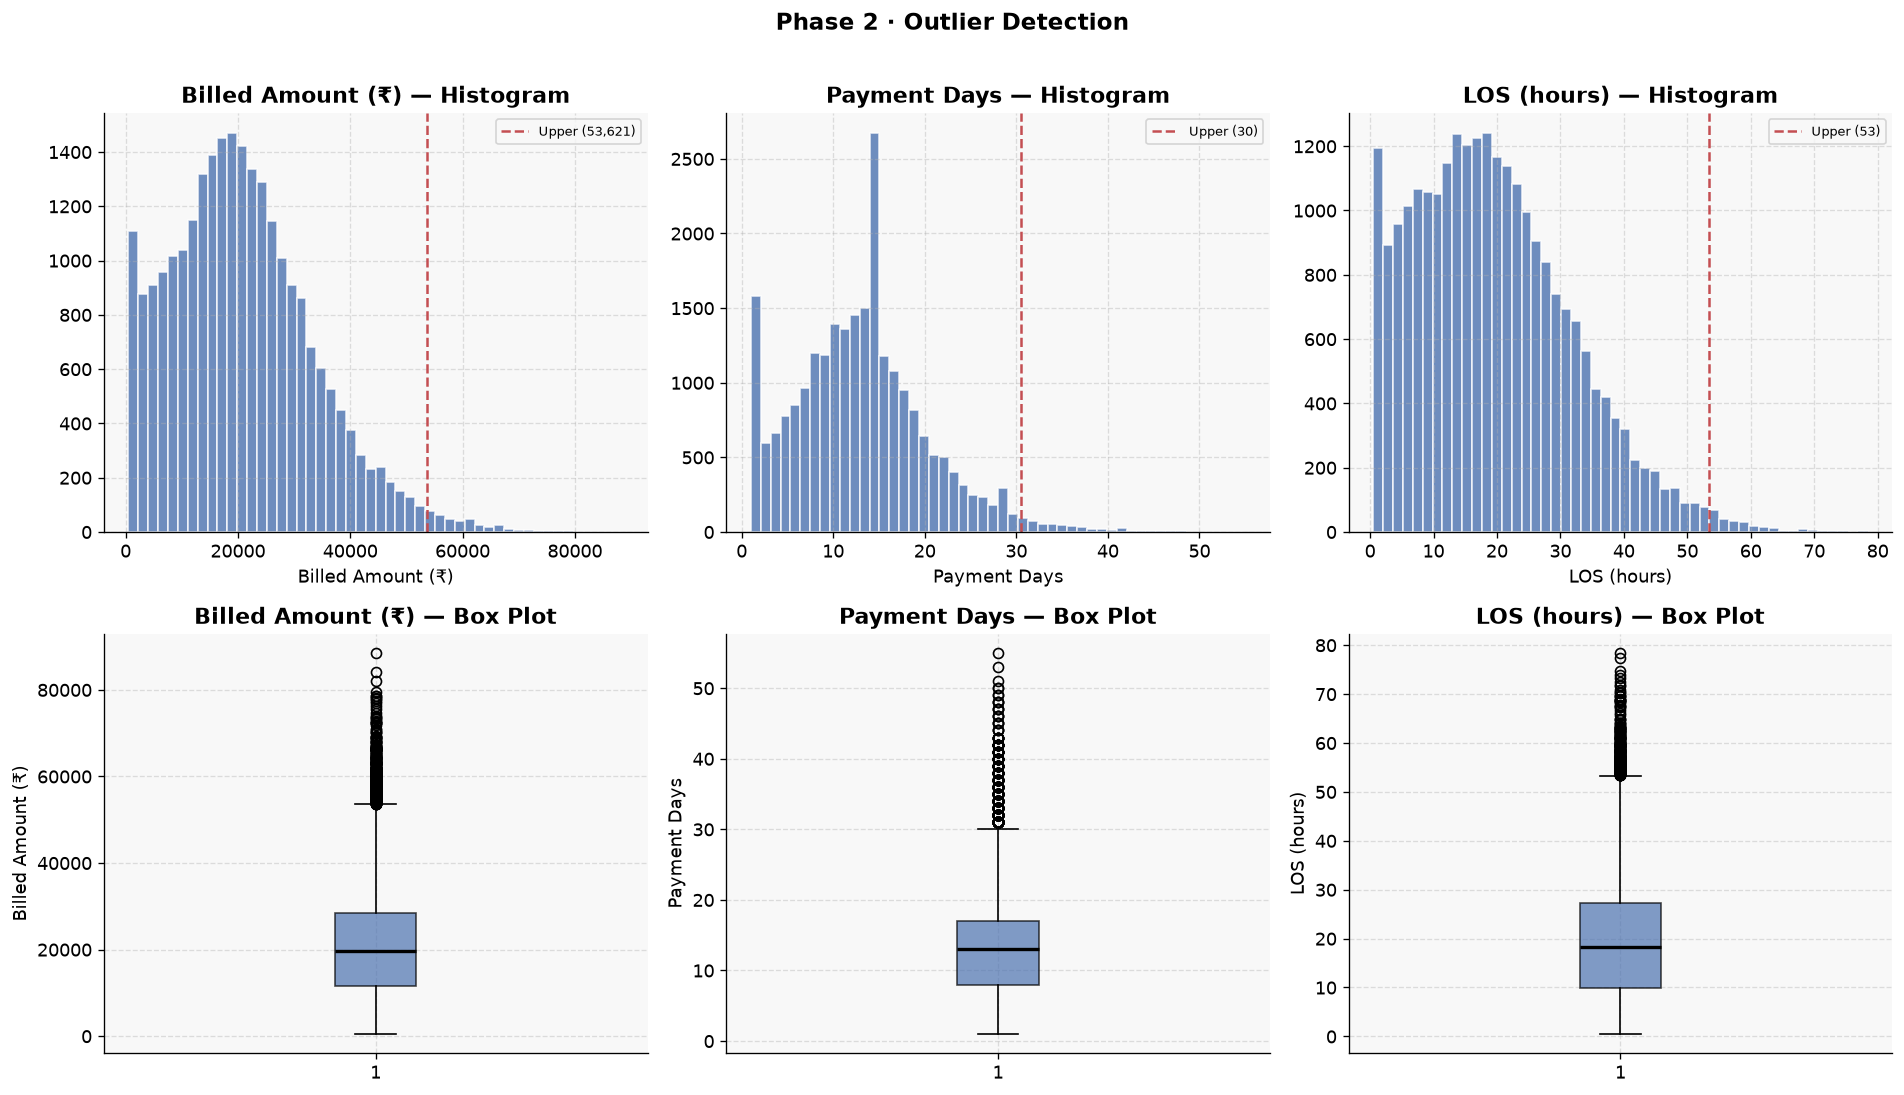

  ✅ Saved → Output_Phase2\outlier_analysis.png
💡 Outlier strategy: CAP at IQR upper fence — do not remove.
   Removing rows in a clinical dataset risks losing real extreme cases.
   Capped values: billed_amount → ₹53,621 | payment_days → 30.5 | LOS → 53.34 hrs


In [11]:
# ── Visualise: histograms + box plots (saved to Output_Phase2/) ───────────────
plot_outliers(df, out=out)


## 6. Correlation Analysis

Checking how numeric features relate to each other before modelling.
Strong correlations between input features (multicollinearity) can reduce
model interpretability — we use this to inform feature selection.


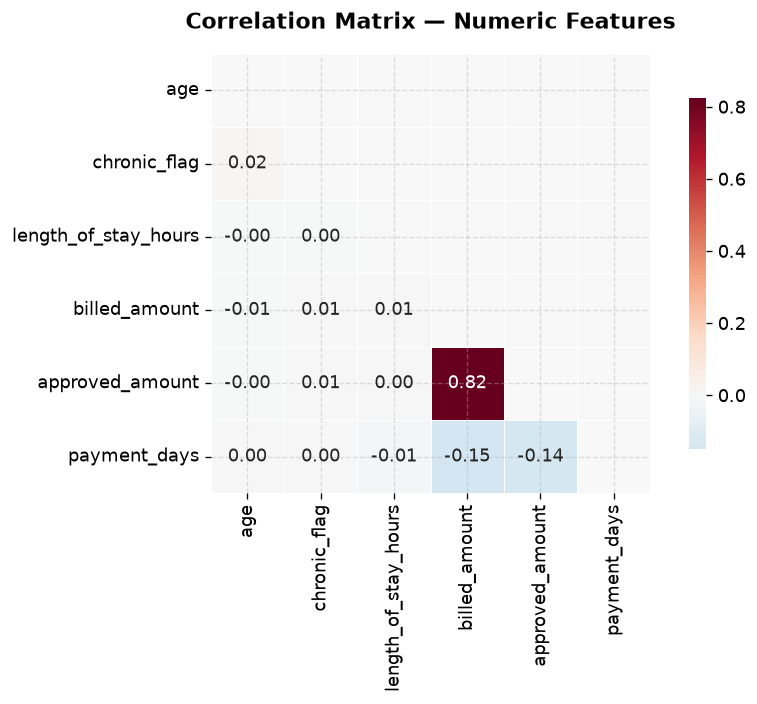

  ✅ Saved → Output_Phase2\correlation_heatmap.png
💡 Key observations:
   - billed_amount & approved_amount: strongly correlated (expected — approved ≤ billed).
   - age & chronic_flag: low correlation — both useful as independent features.
   - length_of_stay & billed_amount: low — billing is not purely time-based.


In [12]:
plot_correlation(df, out=out)


## 7. Feature Engineering

**Rubric requirement:** Engineer features including visit frequency,
average length of stay per patient, provider rejection rate,
days since registration, and time-based features.

All 11 features are created with a **single call** to `engineer_features()`
from `phase1_utils.py`. This exact same function is reused in Phase 3
(training), Phase 5 (API inference), and Phase 6 (monitoring) — guaranteeing
identical logic everywhere with no duplication.

| # | Feature | Source | Business reason |
|---|---|---|---|
| 1 | `visit_frequency` | patient_id, visit_id | Frequent patients may be chronic or complex |
| 2 | `avg_los_per_patient` | patient_id, LOS | Patient-level baseline for stay duration |
| 3 | `provider_rejection_rate` | insurance_provider | Historical rejection rate of their insurer |
| 4 | `days_since_registration` | registration_date, visit_date | Newer patients behave differently |
| 5 | `approval_ratio` | approved_amount, billed_amount | How much of the bill was approved |
| 6 | `billed_amount_capped` | billed_amount | Outlier-capped — limits extreme influence |
| 7 | `payment_days_capped` | payment_days | Outlier-capped — 0 for unpaid claims |
| 8 | `los_capped` | length_of_stay_hours | Outlier-capped length of stay |
| 9 | `visit_month` | visit_date | Seasonal hospital load patterns |
| 10 | `visit_dayofweek` | visit_date | Weekday vs weekend visit patterns |
| 11 | `visit_quarter` | visit_date | Financial cycle alignment |


In [13]:
# ── One call — all 11 features ────────────────────────────────────────────────
df_feat = engineer_features(df)

# ── Verify all features exist with 0 nulls ────────────────────────────────────
engineered = [
    'visit_frequency', 'avg_los_per_patient', 'provider_rejection_rate',
    'days_since_registration', 'approval_ratio',
    'billed_amount_capped', 'payment_days_capped', 'los_capped',
    'visit_month', 'visit_dayofweek', 'visit_quarter',
]

print(f"{'Feature':<30} {'dtype':>12}  {'nulls':>6}  {'min':>8}  {'max':>12}")
print("─" * 74)
for feat in engineered:
    col = df_feat[feat]
    print(f"{feat:<30} {str(col.dtype):>12}  {col.isna().sum():>6}  "
          f"{col.min():>8.2f}  {col.max():>12.2f}")

print(f"\n✅ All {len(engineered)} features engineered — 0 nulls.")


Feature                               dtype   nulls       min           max
──────────────────────────────────────────────────────────────────────────
visit_frequency                       int64       0      1.00         15.00
avg_los_per_patient                 float64       0      0.50         56.23
provider_rejection_rate             float64       0      0.15          0.16
days_since_registration               int64       0      0.00        364.00
approval_ratio                      float64       0      0.00          1.00
billed_amount_capped                float64       0    500.00      53621.49
payment_days_capped                 float64       0      0.00         30.50
los_capped                          float64       0      0.50         53.34
visit_month                           int32       0      1.00         12.00
visit_dayofweek                       int32       0      0.00          6.00
visit_quarter                         int32       0      1.00          4.00

✅ All 11 fea

In [14]:
# ── Spot-check key features ───────────────────────────────────────────────────
print("=== visit_frequency (per patient) ===")
display(df_feat['visit_frequency'].describe().to_frame().T)

print("\n=== approval_ratio (approved / billed) ===")
display(df_feat['approval_ratio'].describe().to_frame().T)

print("\n=== provider_rejection_rate by insurer ===")
display(df_feat.groupby('insurance_provider')['provider_rejection_rate']
        .first().round(4).to_frame())


=== visit_frequency (per patient) ===


,count,mean,std,min,25%,50%,75%,max
visit_frequency,"25,000.00",5.96,2.18,1.00,4.00,6.00,7.00,15.00



=== approval_ratio (approved / billed) ===


,count,mean,std,min,25%,50%,75%,max
approval_ratio,"25,000.00",0.77,0.36,0.00,0.67,1.00,1.00,1.00



=== provider_rejection_rate by insurer ===


,provider_rejection_rate
insurance_provider,
CareOne,0.15
HealthPlus,0.15
MediCareX,0.15
SecureLife,0.16


## 8. Feature vs Target Visualisation

Before passing features to a model we visually confirm that they actually
**differ across target classes**. If a feature distribution looks identical
across all classes, it won't help the model learn.

Two charts are generated:
- **8A** — features vs `risk_score` (Model A target)
- **8B** — features vs `claim_status` (Model B target)


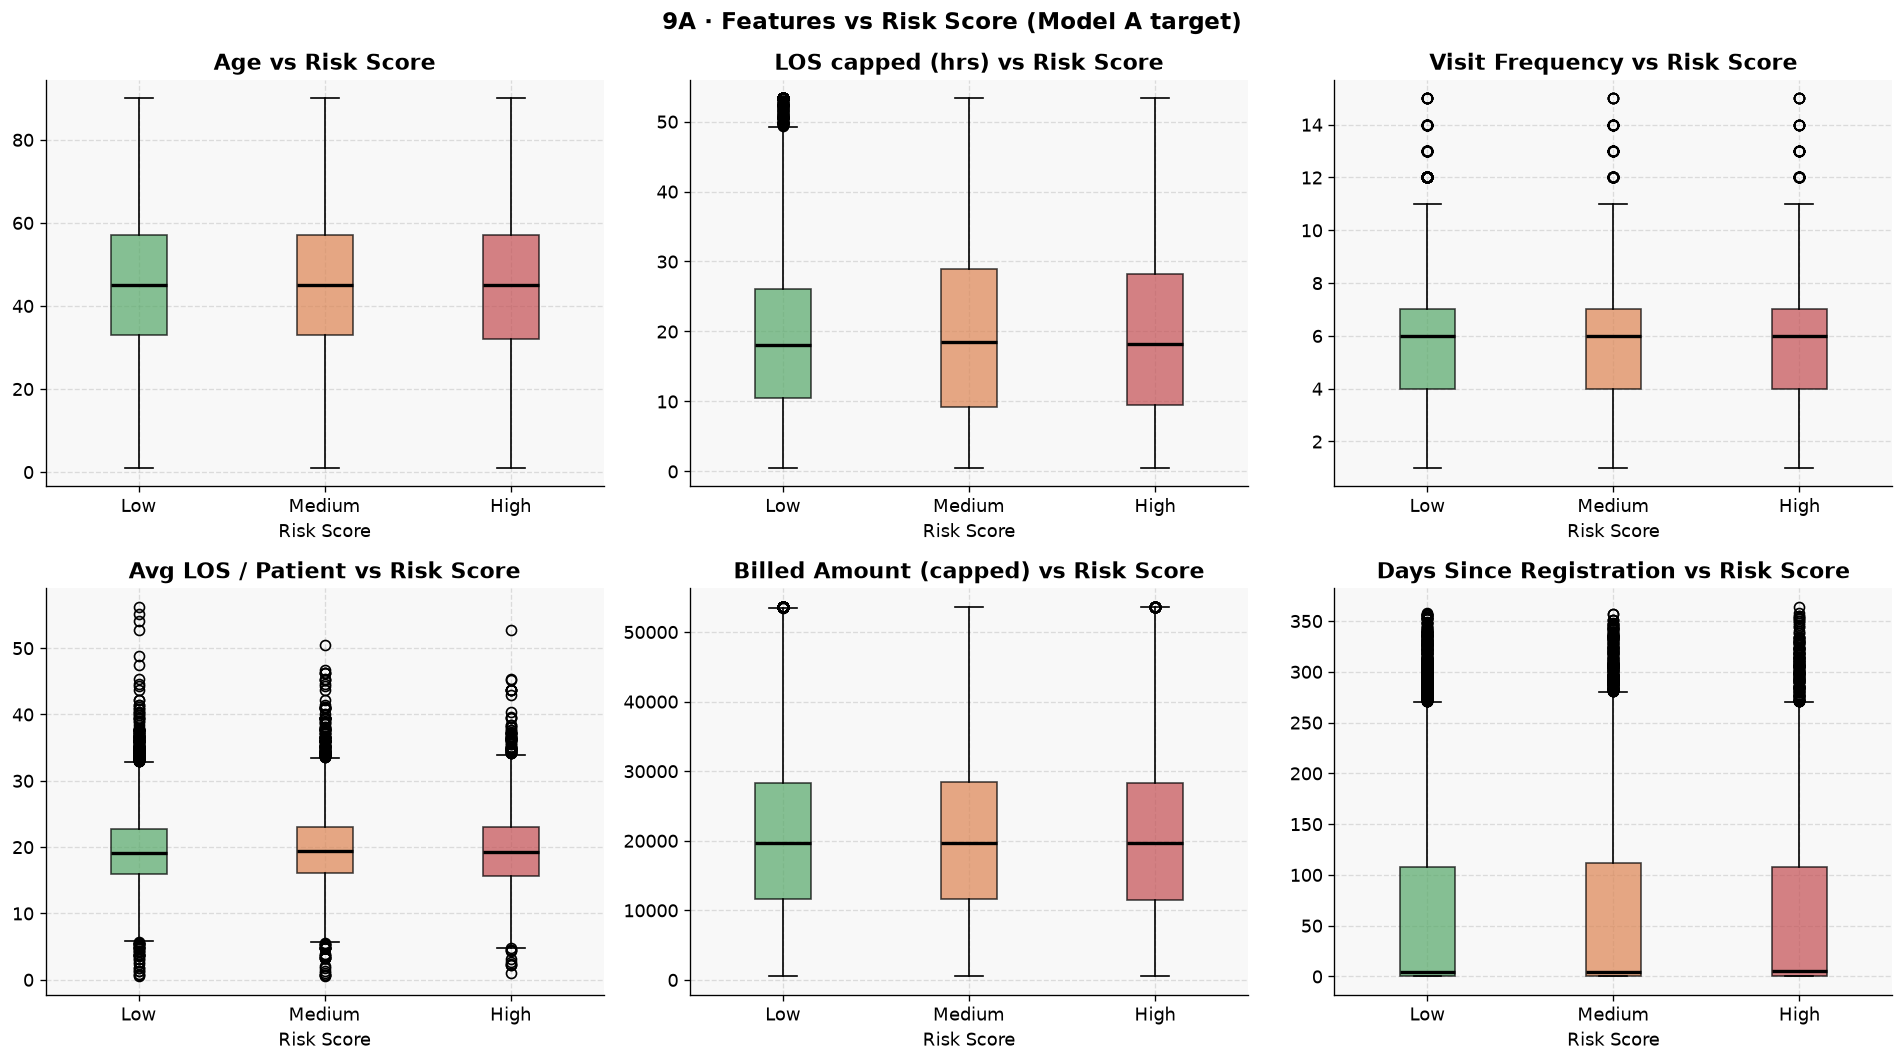

  ✅ Saved → Output_Phase2\feature_vs_risk.png


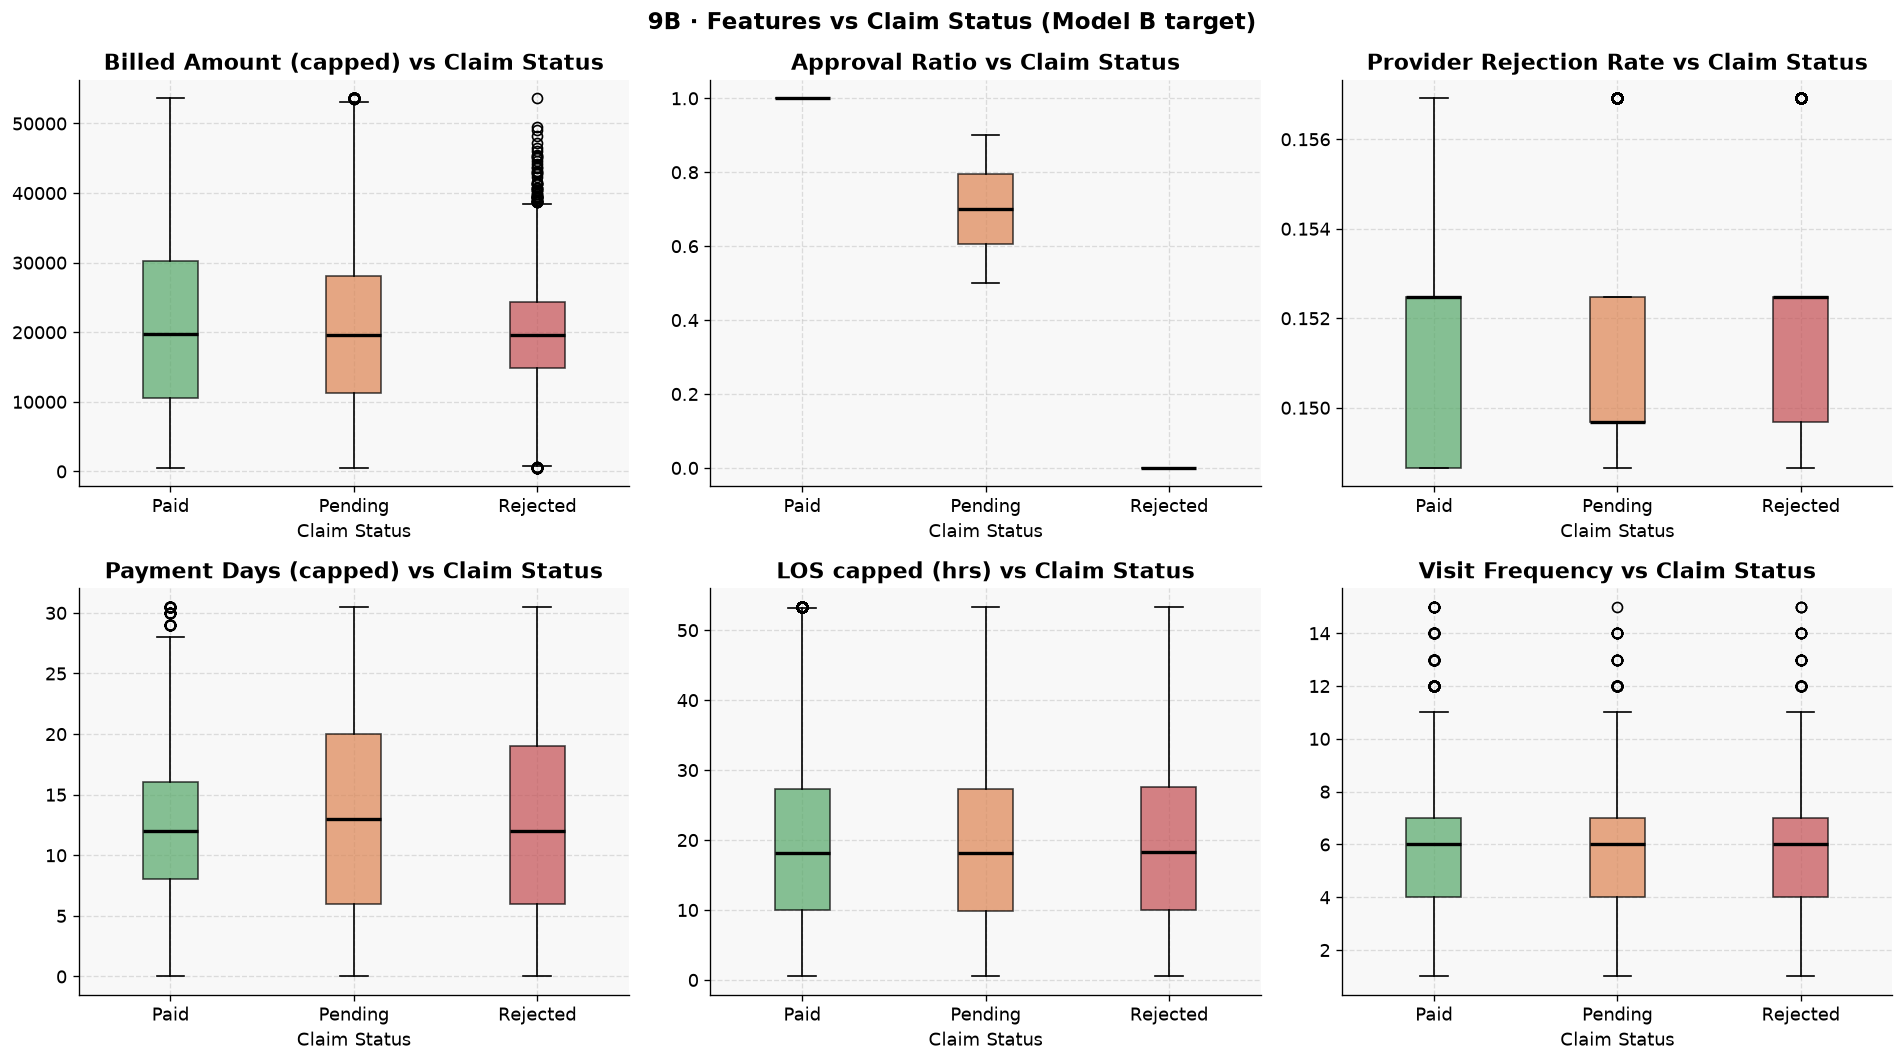

  ✅ Saved → Output_Phase2\feature_vs_claim.png
💡 Key visual findings:
   - approval_ratio cleanly separates Paid (≈1.0) from Rejected (≈0.0).
     This will be the strongest predictor in Model B.
   - billed_amount_capped shows little separation by risk_score —
     tree-based models will find non-linear patterns beyond what box plots show.


In [15]:
# Saves two chart files to Output_Phase2/:
#   feature_vs_risk.png    — 6 features × 3 risk classes
#   feature_vs_claim.png   — 6 features × 3 claim status classes

plot_feature_vs_target(df_feat, out=out)


## 9. Build Model Table & Export

`build_model_table()` from `phase1_utils.py` runs three steps in one call:
1. `engineer_features()` — adds all 11 features
2. `encode_categoricals()` — fixed label encoding (same maps used in Phase 3 & 5)
3. Column selection — keeps only the model-relevant columns

The result — `model_table.csv` — is the direct input to Phase 3.


In [16]:
# ── Build in one call ─────────────────────────────────────────────────────────
model_df = build_model_table(df)

print(f"Model table shape  : {model_df.shape[0]:,} rows × {model_df.shape[1]} columns")
print(f"Null count         : {model_df.isnull().sum().sum()}")
print()
print(f"Model A — {len(MODEL_A_FEATURES)} features  |  target : {MODEL_A_TARGET}")
print(f"Model B — {len(MODEL_B_FEATURES)} features  |  target : {MODEL_B_TARGET}")
print()
display(model_df.head(3))


Model table shape  : 25,000 rows × 30 columns
Null count         : 0

Model A — 18 features  |  target : risk_score_encoded
Model B — 18 features  |  target : claim_status_encoded



,visit_id,patient_id,visit_date,age,chronic_flag,los_capped,visit_frequency,avg_los_per_patient,days_since_registration,billed_amount_capped,approval_ratio,provider_rejection_rate,payment_days_capped,visit_month,visit_dayofweek,visit_quarter,department,visit_type,gender,city,insurance_provider,department_encoded,visit_type_encoded,gender_encoded,city_encoded,insurance_provider_encoded,risk_score,risk_score_encoded,claim_status,claim_status_encoded
0,1,756,2025-10-18,90,1,3.48,2,3.73,65,"23,577.37",0.00,0.15,16.00,10,5,4,Cardiology,ER,M,Bangalore,CareOne,0,0,1,0,0,Low,1,Rejected,2
1,2,4102,2025-04-06,30,1,15.31,4,32.02,0,"38,178.81",1.00,0.16,18.00,4,6,2,Orthopedics,OPD,M,Hyderabad,SecureLife,5,2,1,3,3,High,0,Paid,0
2,3,2964,2025-07-13,25,1,34.36,4,20.54,9,"5,038.97",1.00,0.15,0.00,7,6,3,ICU,ER,F,Chennai,HealthPlus,3,0,0,1,1,Low,1,Paid,0


In [17]:
# ── Null check before saving ──────────────────────────────────────────────────
nulls = model_df.isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) == 0:
    print("✅ No nulls in model table — safe to export.")
else:
    print("⚠️  Remaining nulls (investigate before Phase 3):")
    display(nulls.to_frame('null_count'))


✅ No nulls in model table — safe to export.


In [18]:
import os

# ── Export to Output_Phase2/ ──────────────────────────────────────────────────
csv_path = out('model_table.csv')
model_df.to_csv(csv_path, index=False)

print(f"✅ model_table.csv  →  {csv_path}")
print(f"   {model_df.shape[0]:,} rows × {model_df.shape[1]} columns")
print(f"   File size: {os.path.getsize(csv_path)/1024:.1f} KB")


✅ model_table.csv  →  Output_Phase2\model_table.csv
   25,000 rows × 30 columns
   File size: 3517.6 KB


## 10. Output Summary

In [19]:
import os

print("=== Output_Phase2/ contents ===\n")
total_size = 0
for f in sorted(os.listdir('Output_Phase2')):
    size = os.path.getsize(os.path.join('Output_Phase2', f))
    total_size += size
    print(f"  {f:<40}  {size/1024:>8.1f} KB")

print(f"\n  Total: {total_size/1024:.1f} KB")
print()
print("✅ Phase 2 complete — all deliverables saved to Output_Phase2/")
print("   Next → Phase3_Modeling.ipynb")
print("   Load : model_df = pd.read_csv('Output_Phase2/model_table.csv')")


=== Output_Phase2/ contents ===

  correlation_heatmap.png                       61.0 KB
  dist_city.png                                113.1 KB
  dist_department.png                           88.8 KB
  dist_insurer.png                              97.6 KB
  dist_pie_charts.png                           84.9 KB
  feature_vs_claim.png                         142.2 KB
  feature_vs_risk.png                          146.6 KB
  missing_values.png                            91.4 KB
  model_table.csv                             3517.6 KB
  outlier_analysis.png                         162.0 KB

  Total: 4505.3 KB

✅ Phase 2 complete — all deliverables saved to Output_Phase2/
   Next → Phase3_Modeling.ipynb
   Load : model_df = pd.read_csv('Output_Phase2/model_table.csv')


## 11. Phase 2 Summary & Business Insights

### Data Quality
| Check | Result | Action |
|---|---|---|
| Merged shape | 25,000 rows × 20 columns | ✅ No data loss from join |
| `length_of_stay_hours` nulls | 0 | ✅ Clean |
| `approved_amount` nulls | 1,318 (5.27%) | Informative — imputed by claim status |
| `payment_days` nulls | 790 (3.16%) | Informative — 0 for unpaid claims |
| Duplicate visit IDs | 0 | ✅ Clean |
| Orphan billing records | 0 | ✅ Clean |

### Operational Insights
- Visits are **evenly spread** across all 6 departments (~4,000 each) — no single department is overloaded
- **ICU has the highest High Risk % at 20.79%** — needs most clinical attention
- Pune patients visit most frequently (5.08 avg visits/patient)
- Average length of stay is **19.6 hours** — Neurology longest at 19.72 hrs

### Financial Insights
- Hospital bills **₹52.2 Cr** but realizes only **78.3%** — ~₹11.4 Cr leakage
- Claim rejection rate is **15.2%** — consistent across all 4 insurers (systemic issue)
- SecureLife has the highest rejection rate at **15.69%**
- `approval_ratio` cleanly separates Paid (≈1.0) from Rejected (≈0.0) — **strongest Model B predictor**

### Features Engineered (11 new columns)
All stored in `Output_Phase2/model_table.csv` with 0 nulls and ready for Phase 3.

### Class Imbalance — Action Required in Phase 3
| Model | Minority class | Rate | Mitigation |
|---|---|---|---|
| Model A (risk_score) | High | 20.1% | `class_weight='balanced'` |
| Model B (claim_status) | Rejected | 15.2% | `class_weight='balanced'` |
